# Система поиска товаров на основе дообученной CLIP модели

## Этап 1. Fine-tuning CLIP

In [1]:
import os
import sys
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPModel, CLIPProcessor
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti
VRAM: 17.2 GB


In [28]:
!nvidia-smi

Fri Feb 20 13:35:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.88                 Driver Version: 576.88         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   44C    P8             14W /  165W |    6215MiB /  16380MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Запускаю локально, поскольку с ВМ могут быть проблемы с подключением. Писал об этом и наставнику, но решения не было. Проект третьего спринта тоже делал локально, вроде бы проблем с этим не было.

In [29]:
import torch, transformers, sklearn, numpy, pandas, sys

print(f"Python: {sys.version}")

for lib in [torch, transformers, sklearn, numpy, pandas]:
    print(f"{lib.__name__}: {lib.__version__}")
print(f"CUDA: {torch.version.cuda}")

Python: 3.12.8 | packaged by conda-forge | (main, Dec  5 2024, 14:06:27) [MSC v.1942 64 bit (AMD64)]
torch: 2.5.1
transformers: 4.57.6
sklearn: 1.6.1
numpy: 2.0.1
pandas: 2.2.3
CUDA: 12.4


### 1.1 Загрузка и визуализация данных

Скачиваем с яндекс диска.

In [4]:
#!wget -O archive.zip "https://downloader.disk.yandex.ru/disk/1ea8640dc7d3c0932b21403a026c98daa36c2f94b63e544b741327e4ecb15266/6997b1ba/NCs-PUxgQwoUOIgYF7-VNPQ89uOP102jCL3mJe3dkVZoqJJYgZKGwa68f401WecBN6jm7K-2IzyylxPEmxpJyg%3D%3D?uid=0&filename=archive.zip&disposition=attachment&hash=Qjh8PJJ6Zxgi7l5h%2BeLfw5y8jPqWDGuq9tpiyBKn20MkbUrf1nxjdfxf475WVIJoq/J6bpmRyOJonT3VoXnDag%3D%3D%3A&limit=0&content_type=application%2Fzip&owner_uid=92719142&fsize=3399462774&hid=2481c353b97211c53a6cc4214f1eed9a&media_type=compressed&tknv=v3"

In [5]:
# https://www.kaggle.com/datasets/nirmalsankalana/fashion-product-text-images-dataset

ZIP_NAME = 'archive.zip'
DATA_DIR = './data'

if not os.path.exists(DATA_DIR):
    if sys.platform == 'win32':
        with zipfile.ZipFile(ZIP_NAME, 'r') as zf:
            zf.extractall('.')
    else:
        !unzip -q {ZIP_NAME}
    print('Архив распакован')

CSV_PATH = './data.csv'
IMAGES_DIR = './data'

n_images = len([f for f in os.listdir(IMAGES_DIR) if f.endswith('.jpg')])
print(f'CSV: {CSV_PATH}')
print(f'Images: {IMAGES_DIR} ({n_images} jpg files)')

CSV: ./data.csv
Images: ./data (44441 jpg files)


In [6]:
df = pd.read_csv(CSV_PATH)
print(f'Размер датасета: {df.shape}')
print(f'\nСтолбцы: {list(df.columns)}')
print(f'\nПропуски:\n{df.isnull().sum()}')
print(f'\nДубликаты по image: {df.duplicated(subset=["image"]).sum()}')
print(f'\nКатегории ({df["category"].nunique()}):')
print(df['category'].value_counts().head(15))
df.head()

Размер датасета: (44441, 4)

Столбцы: ['image', 'description', 'display name', 'category']

Пропуски:
image             0
description     281
display name      7
category          0
dtype: int64

Дубликаты по image: 0

Категории (142):
category
Tshirts         7069
Shirts          3215
Casual Shoes    2846
Watches         2542
Sports Shoes    2036
Kurtas          1844
Tops            1762
Handbags        1759
Heels           1323
Sunglasses      1073
Wallets          936
Flip Flops       916
Sandals          897
Briefs           849
Belts            813
Name: count, dtype: int64


,image,description,display name,category
0,3238.jpg,"Round toed, black sports shoes with red accent...",Puma Men Black 65CC Lo Ducati Sports Shoes,Sports Shoes
1,43044.jpg,Style Note Built with the breathability and ze...,Nike Men Charcoal Grey Shorts,Shorts
2,54018.jpg,Teal handbag that has stitch detailing with a...,Kiara Women Teal Handbag,Handbags
3,8141.jpg,"Perfectly stylish, this fastrack analog wrist ...",Fastrack Women Freestyle Sports Analog Steel B...,Watches
4,22245.jpg,These id mid-top chukka shoes add a fresh spin...,ID Men Brown Casual Shoes,Casual Shoes


Визуализация случайных примеров

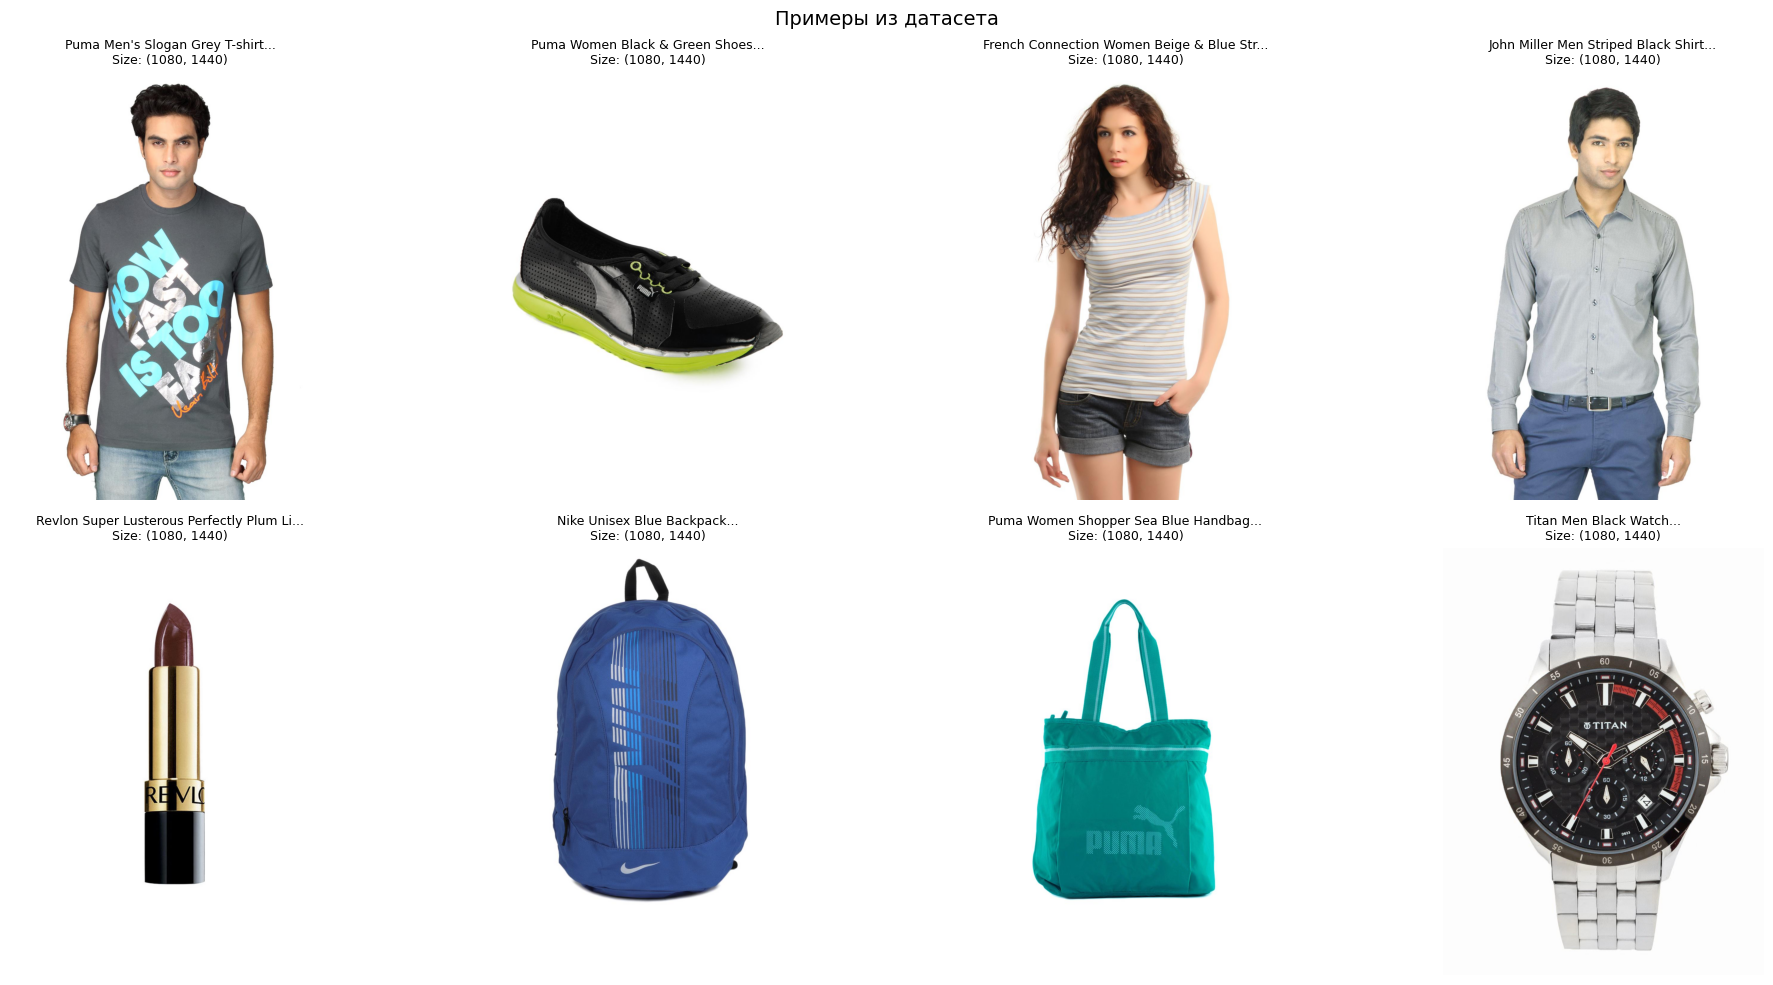

In [7]:
sample_indices = random.sample(range(len(df)), 8)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for idx, ax in zip(sample_indices, axes.flat):
    row = df.iloc[idx]
    img_path = os.path.join(IMAGES_DIR, row['image'])
    if os.path.exists(img_path):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f"{row['display name'][:40]}...\nSize: {img.size}", fontsize=9)
    else:
        ax.set_title(f'Not found: {row["image"]}')
    ax.axis('off')

plt.suptitle('Примеры из датасета', fontsize=14)
plt.tight_layout()
plt.show()

Анализ разрешения картинок

In [8]:
widths, heights = [], []
sample_files = random.sample(os.listdir(IMAGES_DIR), min(500, len(os.listdir(IMAGES_DIR))))
for fname in sample_files:
    try:
        img = Image.open(os.path.join(IMAGES_DIR, fname))
        widths.append(img.size[0])
        heights.append(img.size[1])
    except:
        pass

print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')

Width  — min: 1080, max: 1080, mean: 1080
Height — min: 1440, max: 1440, mean: 1440


Анализ текстовых описаний

In [9]:
desc_lens = df['description'].dropna().apply(len)
print(f'Длина описаний — min: {desc_lens.min()}, max: {desc_lens.max()}, mean: {desc_lens.mean():.0f}')

# Проверяем соответствие описаний картинкам — 3 случайных примера
print('\n--- Примеры описаний ---')
for i in random.sample(range(len(df)), 3):
    row = df.iloc[i]
    print(f'\nImage: {row["image"]}')
    print(f'Display name: {row["display name"]}')
    print(f'Description (first 200 chars): {str(row["description"])[:200]}')
    print('---')

Длина описаний — min: 1, max: 28466, mean: 556

--- Примеры описаний ---

Image: 27218.jpg
Display name: Doodle Kids Boy Printed Blue Shorts
Description (first 200 chars): Composition Blue and white printed shorts that have two side pockets, two back pockets, pin tucks above the hem on either sides, a buttoned and zipped closure and loops on the waist   Fit  Regular   W
---

Image: 30918.jpg
Display name: Fabindia Women Beige Harem Pants
Description (first 200 chars): Composition Beige harem crinkled pants made of cotton mull, has waistband with drawstrings and fabric piping along the hem   Fit  Regular   Wash  care  Hand wash separately in cold water using mild de
---

Image: 38746.jpg
Display name: Nike Unisex Blue Backpack
Description (first 200 chars): Style note If you want a bag that is funky, stylish, super cool and comfortable to carry around all day, check out this backpack from nike. Carry it to college or on a casual day out with your friends
---


**Выводы по данным:**
- Датасет содержит 44441 изображений товаров одежды/аксессуаров (142 категории). Топ: Tshirts, Shirts, Casual Shoes, Watches.
- Все картинки одного разрешения 1080×1440, белый/нейтральный фон. Разброса по размерам нет, CLIP processor приведёт к нужному формату автоматически.
- 281 пропуск в description, 7 в display name — будут удалены при очистке.
- Описания подробные (средняя длина 556 символов), содержат цвет, материал, стиль. CLIP processor обрежет до 77 токенов, но ключевая информация обычно в начале описания.
- Дубликатов по image нет.

### 1.2 Предобработка данных

In [10]:
print(f'До очистки: {len(df)}')

# Убираем пропуски в description и image
df = df.dropna(subset=['image', 'description'])
df = df[df['description'].str.strip() != '']
df = df[df['image'].str.strip() != '']
print(f'После удаления пропусков: {len(df)}')

# Убираем дубликаты по image
df = df.drop_duplicates(subset=['image'], keep='first')
print(f'После удаления дубликатов по image: {len(df)}')

# Убираем дубликаты по description
df = df.drop_duplicates(subset=['description'], keep='first')
print(f'После удаления дубликатов по description: {len(df)}')

# Проверяем что картинки реально существуют
df['img_exists'] = df['image'].apply(lambda x: os.path.exists(os.path.join(IMAGES_DIR, x)))
print(f'Картинок не найдено: {(~df["img_exists"]).sum()}')
df = df[df['img_exists']].drop(columns=['img_exists'])
print(f'Итого: {len(df)}')

df = df.reset_index(drop=True)

До очистки: 44441
После удаления пропусков: 44158
После удаления дубликатов по image: 44158
После удаления дубликатов по description: 38854
Картинок не найдено: 0
Итого: 38854


In [11]:
# Разделение на train и test (10% тест)
train_df, test_df = train_test_split(df, test_size=0.1, random_state=SEED)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)}')
print(f'Test:  {len(test_df)}')

Train: 34968
Test:  3886


**Выводы по предобработке:**
- Удалено 283 строки с пропусками в description/display name.
- Дубликатов по image нет. Удалено ~5300 дубликатов по description — разные товары с одинаковым текстом (например, один товар в нескольких цветах). Такие дубликаты вредят contrastive learning.
- Все картинки на месте, битых файлов нет.
- Итого 38854 пар (image, text). Train/test split: 34968 / 3886 (90/10).

Дубликаты по description — разные картинки с одинаковым текстовым описанием. Таким видим оказалось очень много ~5300. По идее мы их убираем, потому что для CLIP-обучения это вредно — модель получает один и тот же текст, но разные картинки, и не понимает куда тянуть эмбеддинг. Это шум в contrastive learning. В contrastive loss каждый батч строит матрицу: правильная пара (image, text) на диагонали, всё остальное — негативные примеры. Если в батче попадётся две разные картинки с одинаковым текстом, модель получает противоречивый сигнал — один текст должен быть близко к картинке A и далеко от картинки B, но при этом B имеет тот же текст. Модель не знает что делать и учится хуже.

### 1.3 Класс датасета

In [12]:
class FashionCLIPDataset(Dataset):
    """Датасет для пар (изображение, текстовое описание)."""
    
    def __init__(self, dataframe, images_dir, processor, max_length=77):
        self.df = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.processor = processor
        self.max_length = max_length
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['image'])
        image = Image.open(img_path).convert('RGB')
        text = str(row['description'])
        
        inputs = self.processor(
            text=[text],
            images=image,
            return_tensors='pt',
            padding='max_length',
            truncation=True,
            max_length=self.max_length
        )
        
        return {
            'input_ids': inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0),
            'pixel_values': inputs['pixel_values'].squeeze(0),
        }

### 1.4 Загрузка модели и проверка CLIP-скоров до дообучения

In [13]:
MODEL_NAME = 'openai/clip-vit-base-patch32'

processor = CLIPProcessor.from_pretrained(MODEL_NAME, use_fast=True)
# model = CLIPModel.from_pretrained(MODEL_NAME) # для ВМ
model = CLIPModel.from_pretrained(MODEL_NAME, use_safetensors=True) # для моей локалки
model = model.to(device)

print(f'Model loaded: {MODEL_NAME}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M')

Model loaded: openai/clip-vit-base-patch32
Parameters: 151.3M


Проверяем CLIP-скоры на нескольких примерах **ДО дообучения**

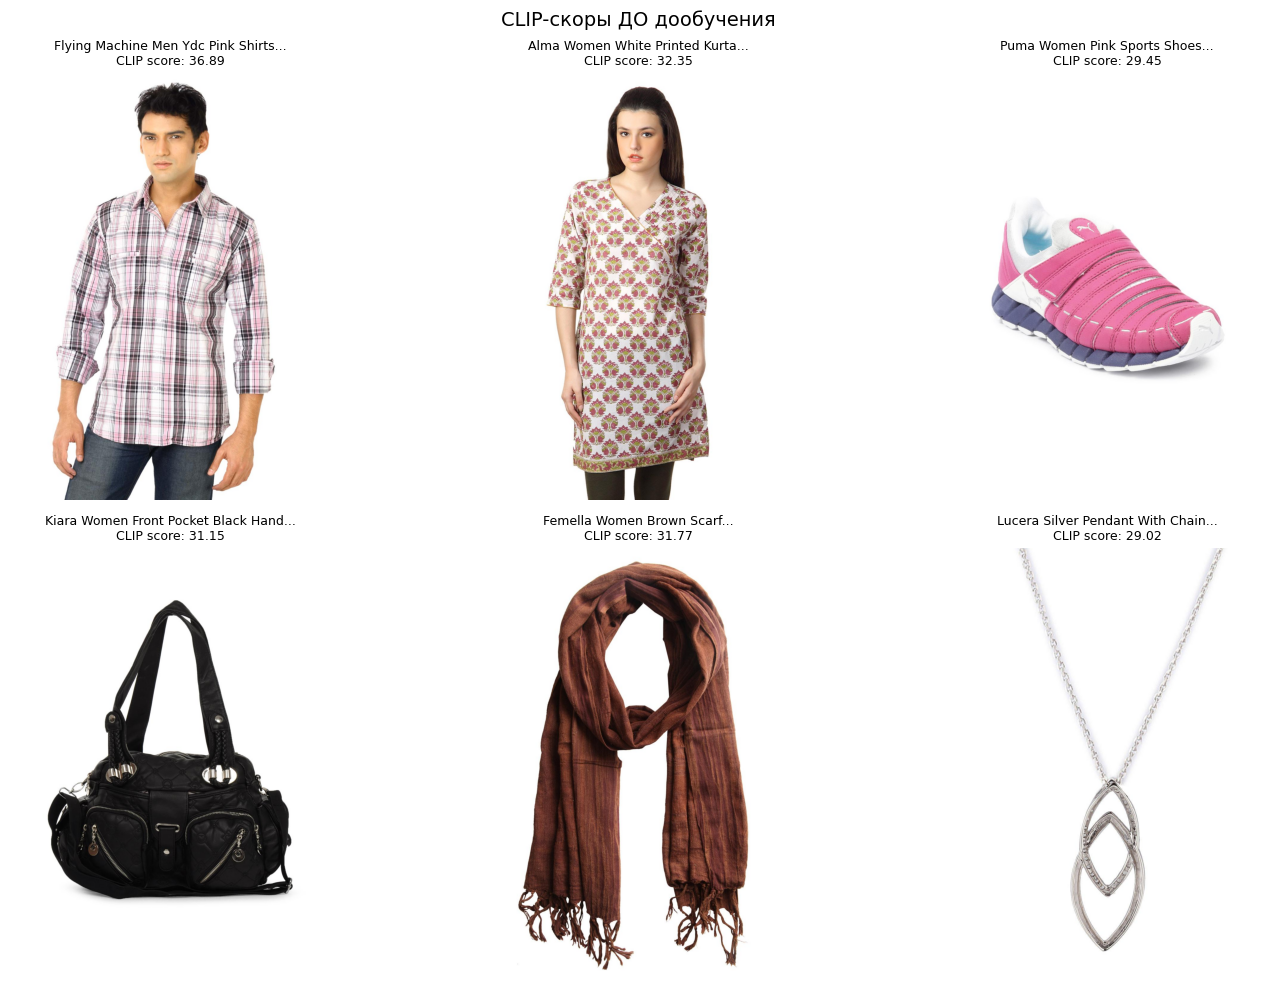

In [14]:
model.eval()
sample_indices = random.sample(range(len(df)), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, ax in zip(sample_indices, axes.flat):
    row = df.iloc[idx]
    img_path = os.path.join(IMAGES_DIR, row['image'])
    image = Image.open(img_path).convert('RGB')
    text = str(row['description'])[:200]
    
    inputs = processor(text=[text], images=image, return_tensors='pt',
                       padding='max_length', truncation=True, max_length=77)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits_per_image
        clip_score = logits.item()
    
    ax.imshow(image)
    ax.set_title(f'{row["display name"][:35]}...\nCLIP score: {clip_score:.2f}', fontsize=9)
    ax.axis('off')

plt.suptitle('CLIP-скоры ДО дообучения', fontsize=14)
plt.tight_layout()
plt.show()

### 1.5 Дообучение модели

In [15]:
BATCH_SIZE = 32
NUM_EPOCHS = 5
LR = 5e-6
CHECKPOINT_DIR = './checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

train_dataset = FashionCLIPDataset(train_df, IMAGES_DIR, processor)
test_dataset = FashionCLIPDataset(test_df, IMAGES_DIR, processor)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True) # vm
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True) # vm

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 1093
Test batches:  122


In [16]:
def clip_loss(logits_per_image, logits_per_text):
    """Стандартная симметричная CLIP loss (contrastive)."""
    batch_size = logits_per_image.shape[0]
    labels = torch.arange(batch_size, device=logits_per_image.device)
    loss_i2t = nn.functional.cross_entropy(logits_per_image, labels)
    loss_t2i = nn.functional.cross_entropy(logits_per_text, labels)
    return (loss_i2t + loss_t2i) / 2


def compute_clip_score(logits_per_image):
    """Средний CLIP score — среднее значение на диагонали logits."""
    return torch.diag(logits_per_image).mean().item()

In [17]:
@torch.no_grad()
def validate(model, dataloader, device):
    """Средний CLIP score на всей валидационной выборке."""
    model.eval()
    total_score = 0.0
    total_samples = 0
    
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            pixel_values=batch['pixel_values']
        )
        scores = torch.diag(outputs.logits_per_image)
        total_score += scores.sum().item()
        total_samples += scores.shape[0]
    
    return total_score / total_samples

In [18]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

# Логи
train_losses = [] # loss per batch
train_clip_scores = [] # clip score per batch
val_clip_scores = [] # clip score per epoch
epoch_avg_losses = [] # average loss per epoch
epoch_avg_scores = [] # average clip score per epoch

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_losses = []
    epoch_scores = []
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}')
    for batch in pbar:
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            pixel_values=batch['pixel_values']
        )
        
        loss = clip_loss(outputs.logits_per_image, outputs.logits_per_text)
        score = compute_clip_score(outputs.logits_per_image)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loss_val = loss.item()
        train_losses.append(loss_val)
        train_clip_scores.append(score)
        epoch_losses.append(loss_val)
        epoch_scores.append(score)
        
        pbar.set_postfix({'loss': f'{loss_val:.4f}', 'clip_score': f'{score:.2f}'})
    
    # Средние за эпоху
    avg_loss = np.mean(epoch_losses)
    avg_score = np.mean(epoch_scores)
    epoch_avg_losses.append(avg_loss)
    epoch_avg_scores.append(avg_score)
    
    # Валидация
    val_score = validate(model, test_loader, device)
    val_clip_scores.append(val_score)
    
    print(f'Epoch {epoch+1}: train_loss={avg_loss:.4f}, train_clip_score={avg_score:.2f}, val_clip_score={val_score:.2f}')
    
    # Чекпоинт
    ckpt_path = os.path.join(CHECKPOINT_DIR, f'clip_epoch_{epoch+1}.pt')
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': avg_loss,
        'val_clip_score': val_score,
    }, ckpt_path)
    print(f'Checkpoint saved: {ckpt_path}')

print('\nОбучение завершено!')

Epoch 1/5: 100%|██████████| 1093/1093 [16:27<00:00,  1.11it/s, loss=0.0327, clip_score=30.52]


Epoch 1: train_loss=0.2650, train_clip_score=29.78, val_clip_score=30.36
Checkpoint saved: ./checkpoints\clip_epoch_1.pt


Epoch 2/5: 100%|██████████| 1093/1093 [16:27<00:00,  1.11it/s, loss=0.0852, clip_score=29.99]


Epoch 2: train_loss=0.1485, train_clip_score=30.63, val_clip_score=30.16
Checkpoint saved: ./checkpoints\clip_epoch_2.pt


Epoch 3/5: 100%|██████████| 1093/1093 [16:25<00:00,  1.11it/s, loss=0.1517, clip_score=31.67]


Epoch 3: train_loss=0.1076, train_clip_score=30.99, val_clip_score=30.57
Checkpoint saved: ./checkpoints\clip_epoch_3.pt


Epoch 4/5: 100%|██████████| 1093/1093 [16:28<00:00,  1.11it/s, loss=0.0835, clip_score=30.59]


Epoch 4: train_loss=0.0889, train_clip_score=31.38, val_clip_score=30.32
Checkpoint saved: ./checkpoints\clip_epoch_4.pt


Epoch 5/5: 100%|██████████| 1093/1093 [16:15<00:00,  1.12it/s, loss=0.0310, clip_score=30.70]


Epoch 5: train_loss=0.0759, train_clip_score=31.44, val_clip_score=30.54
Checkpoint saved: ./checkpoints\clip_epoch_5.pt

Обучение завершено!


### 1.6 Кривые обучения

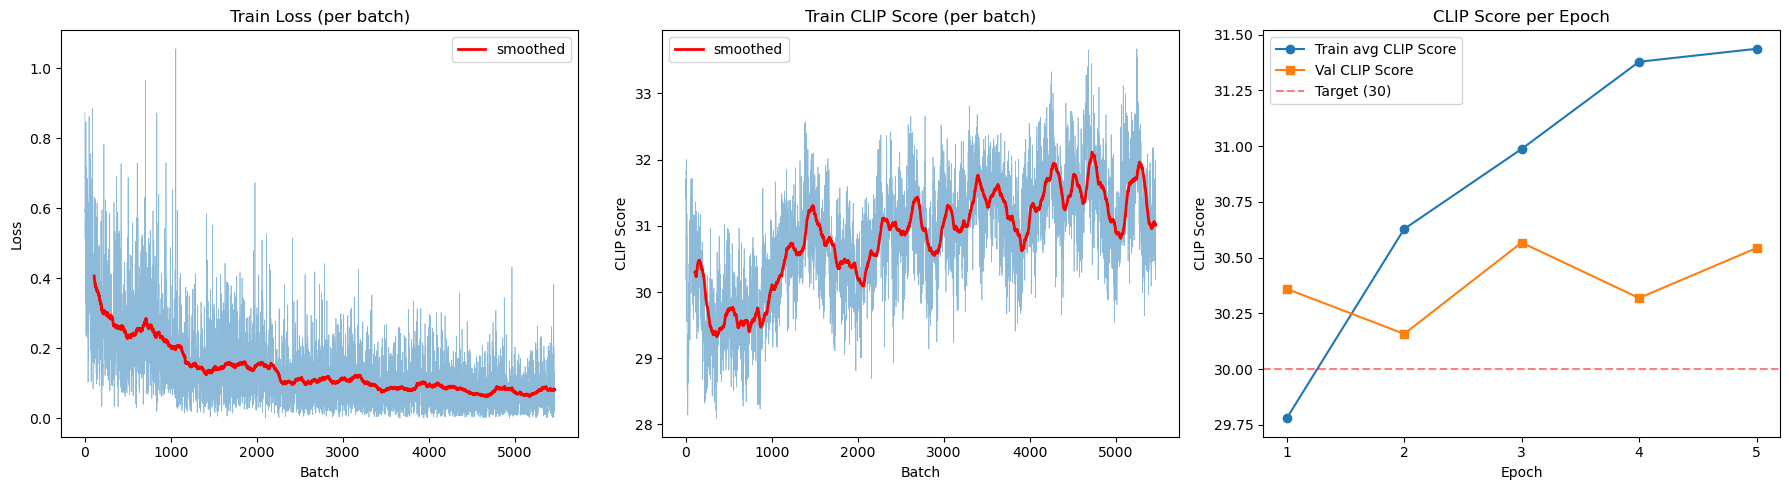

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss по батчам
axes[0].plot(train_losses, alpha=0.5, linewidth=0.5)
# Добавляем скользящее среднее
window = max(1, len(train_losses) // 50)
if len(train_losses) > window:
    smoothed = pd.Series(train_losses).rolling(window).mean()
    axes[0].plot(smoothed, color='red', linewidth=2, label='smoothed')
axes[0].set_title('Train Loss (per batch)')
axes[0].set_xlabel('Batch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. CLIP Score по батчам (train)
axes[1].plot(train_clip_scores, alpha=0.5, linewidth=0.5)
if len(train_clip_scores) > window:
    smoothed_s = pd.Series(train_clip_scores).rolling(window).mean()
    axes[1].plot(smoothed_s, color='red', linewidth=2, label='smoothed')
axes[1].set_title('Train CLIP Score (per batch)')
axes[1].set_xlabel('Batch')
axes[1].set_ylabel('CLIP Score')
axes[1].legend()

# 3. CLIP Score по эпохам — train vs val
epochs_x = range(1, NUM_EPOCHS + 1)
axes[2].plot(epochs_x, epoch_avg_scores, 'o-', label='Train avg CLIP Score')
axes[2].plot(epochs_x, val_clip_scores, 's-', label='Val CLIP Score')
axes[2].axhline(y=30, color='r', linestyle='--', alpha=0.5, label='Target (30)')
axes[2].set_title('CLIP Score per Epoch')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('CLIP Score')
axes[2].legend()
axes[2].set_xticks(list(epochs_x))

plt.tight_layout()
plt.show()

In [23]:
best_epoch = np.argmax(val_clip_scores) + 1
print(f'Лучшая эпоха: {best_epoch}')
print(f'  Train CLIP Score: {epoch_avg_scores[best_epoch-1]:.2f}')
print(f'  Val CLIP Score:   {val_clip_scores[best_epoch-1]:.2f}')
print(f'Чекпоинт: ./checkpoints/clip_epoch_{best_epoch}.pt')

Лучшая эпоха: 3
  Train CLIP Score: 30.99
  Val CLIP Score:   30.57
Чекпоинт: ./checkpoints/clip_epoch_3.pt


**Выводы по обучению:**
- Loss уверенно снижается, CLIP score растёт — обучение сошлось.
- Все эпохи превышают целевое значение CLIP score > 30.
- Лучший val CLIP score на эпохе 3 (30.57). После неё train score растёт, а val стагнирует — признак начала переобучения.
- Для этапа 2 берём чекпоинт эпохи 3.

## Этап 2. Реализация системы поиска товаров

### 2.1 Предвычисление эмбеддингов изображений

Загружаем лучший чекпоинт

In [24]:
best_ckpt = os.path.join(CHECKPOINT_DIR, f'clip_epoch_{best_epoch}.pt')
checkpoint = torch.load(best_ckpt, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded checkpoint: {best_ckpt}')
print(f'Val CLIP Score: {checkpoint["val_clip_score"]:.2f}')

C:\Temp\ipykernel_8308\2824969579.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt, map_location=device)


Loaded checkpoint: ./checkpoints\clip_epoch_3.pt
Val CLIP Score: 30.57


Берём весь датасет для системы поиска

In [25]:
full_df = df.reset_index(drop=True)

all_image_embeddings = []
valid_indices = []

EMBED_BATCH = 64

model.eval()
with torch.no_grad():
    for start_idx in tqdm(range(0, len(full_df), EMBED_BATCH), desc='Computing image embeddings'):
        end_idx = min(start_idx + EMBED_BATCH, len(full_df))
        batch_images = []
        batch_indices = []
        
        for i in range(start_idx, end_idx):
            row = full_df.iloc[i]
            img_path = os.path.join(IMAGES_DIR, row['image'])
            try:
                img = Image.open(img_path).convert('RGB')
                batch_images.append(img)
                batch_indices.append(i)
            except:
                continue
        
        if not batch_images:
            continue
        
        inputs = processor(images=batch_images, return_tensors='pt', padding=True)
        pixel_values = inputs['pixel_values'].to(device)
        
        image_features = model.get_image_features(pixel_values=pixel_values)
        # Нормализуем
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        
        all_image_embeddings.append(image_features.cpu())
        valid_indices.extend(batch_indices)

image_embeddings = torch.cat(all_image_embeddings, dim=0)
print(f'Image embeddings shape: {image_embeddings.shape}')
print(f'Valid images: {len(valid_indices)}')

# Сохраняем эмбеддинги
torch.save({
    'embeddings': image_embeddings,
    'indices': valid_indices
}, './image_embeddings.pt')
print('Embeddings saved!')

Computing image embeddings: 100%|██████████| 608/608 [13:47<00:00,  1.36s/it]


Image embeddings shape: torch.Size([38854, 512])
Valid images: 38854
Embeddings saved!


### 2.2 Функция поиска товаров

In [26]:
def search_products(model, processor, image_embeddings, valid_indices, full_df,
                    text_query, images_dir, top_k=5, device='cuda'):
    """
    Поиск товаров по текстовому запросу.
    
    Args:
        model: наша дообученная CLIP модель
        processor: CLIP processor
        image_embeddings: предвычисленные эмбеддинги изображений (нормализованные)
        valid_indices: индексы валидных изображений в full_df
        full_df: полный датафрейм
        text_query: текстовый запрос
        images_dir: путь к директории с изображениями
        top_k: количество результатов
        device: устройство
    
    Returns:
        (image_path, display_name, category, similarity_score)
    """
    model.eval()
    
    # Получаем эмбеддинг текста
    text_inputs = processor(text=[text_query], return_tensors='pt',
                           padding='max_length', truncation=True, max_length=77)
    text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
    
    with torch.no_grad():
        text_features = model.get_text_features(
            input_ids=text_inputs['input_ids'],
            attention_mask=text_inputs['attention_mask']
        )
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    
    # Считаем cosine similarity с предвычисленными эмбеддингами
    text_features_cpu = text_features.cpu()
    similarities = (image_embeddings @ text_features_cpu.T).squeeze(1)
    
    # Top-K
    top_k_values, top_k_indices = similarities.topk(top_k)
    
    results = []
    for score, emb_idx in zip(top_k_values, top_k_indices):
        df_idx = valid_indices[emb_idx.item()]
        row = full_df.iloc[df_idx]
        img_path = os.path.join(images_dir, row['image'])
        results.append((
            img_path,
            row['display name'],
            row['category'],
            score.item()
        ))
    
    return results


def show_search_results(results, query, cols=5):
    """Визуализация результатов поиска."""
    n = len(results)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 5 * rows))
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    else:
        axes = axes.flat
    
    for i, ax in enumerate(axes if isinstance(axes, list) else list(axes)):
        if i < n:
            img_path, name, category, score = results[i]
            try:
                img = Image.open(img_path)
                ax.imshow(img)
                ax.set_title(f'{name[:40]}\n[{category}]\nscore: {score:.4f}', fontsize=8)
            except:
                ax.set_title('Image not found')
        ax.axis('off')
    
    plt.suptitle(f'Query: "{query}"', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 2.3 Тестирование поисковой системы

- красная юбка
- синие солнцезащитные очки
- микки маус
- черные кожанные ботинки
- белая спортивная обувь
- голубые носки
- белые спортивные часы
- красивое платье для девочек
- фиолетовый галстук
- бежевая сумка
- красный лифчик
- багровая помада
- голубые сандали
- темно-синяя футболка
- мужские желтые штаны

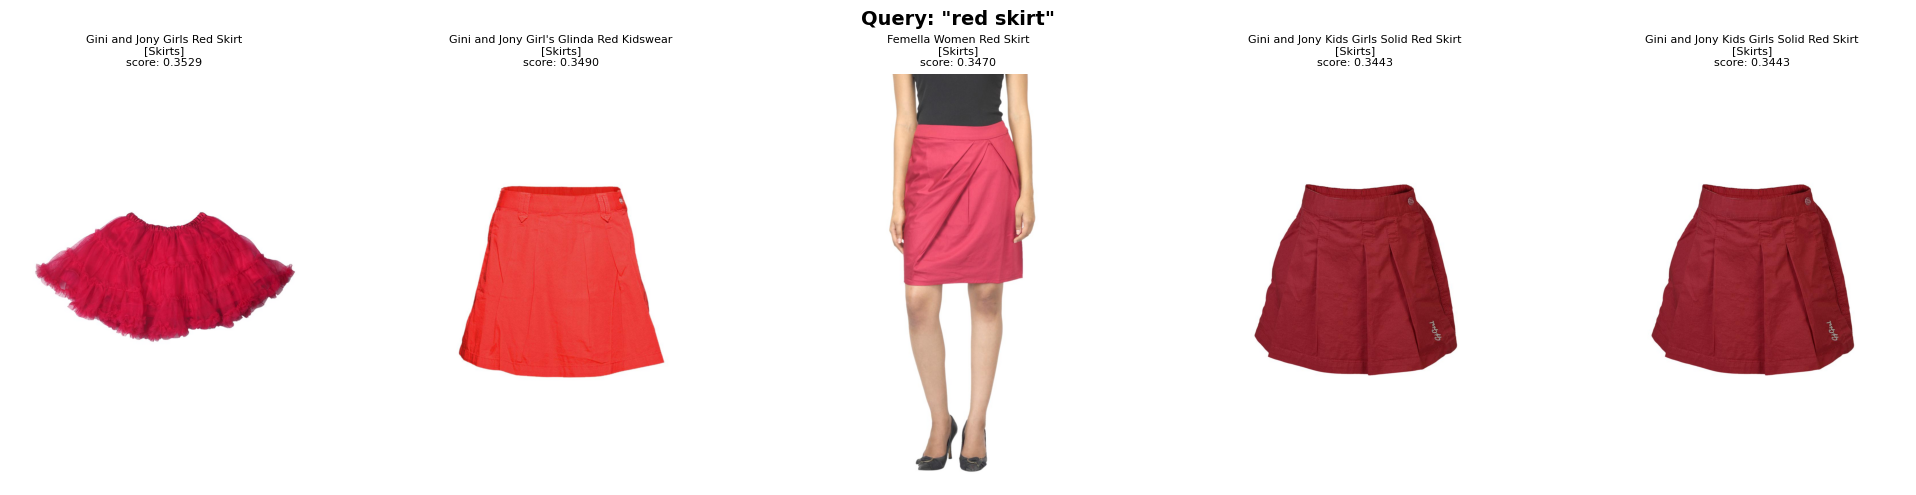

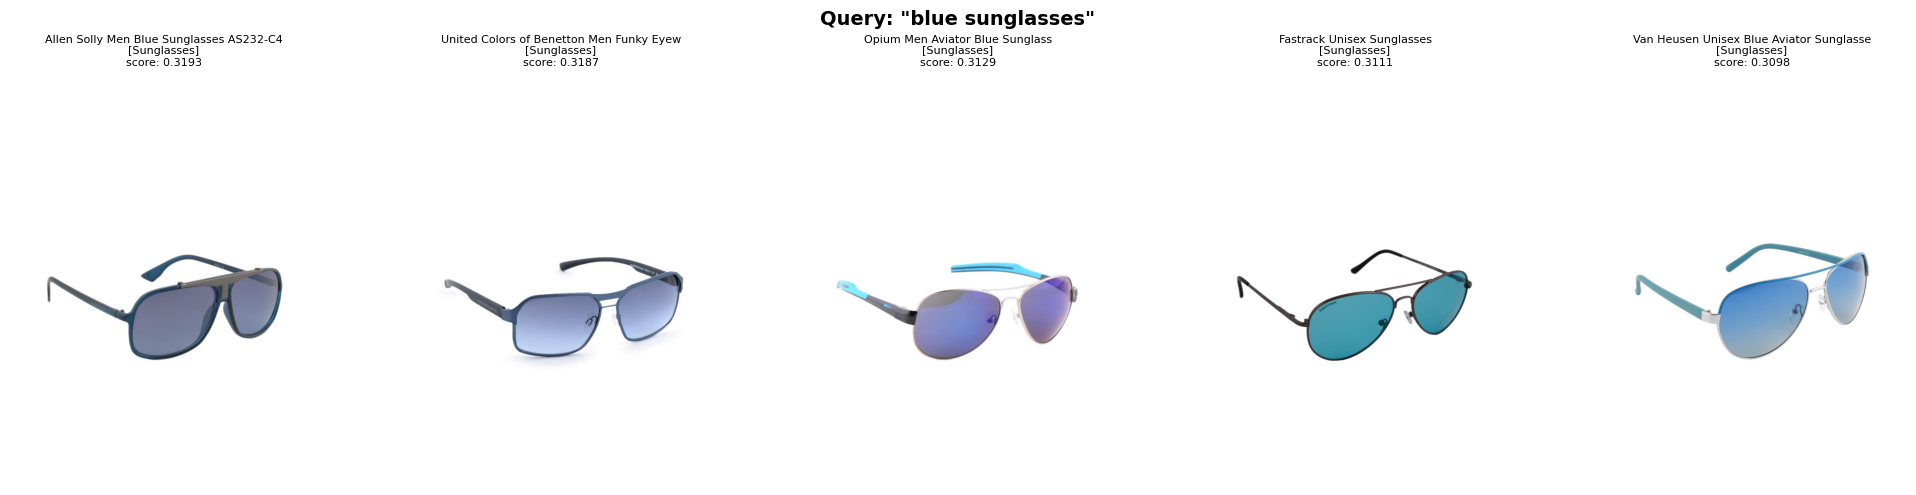

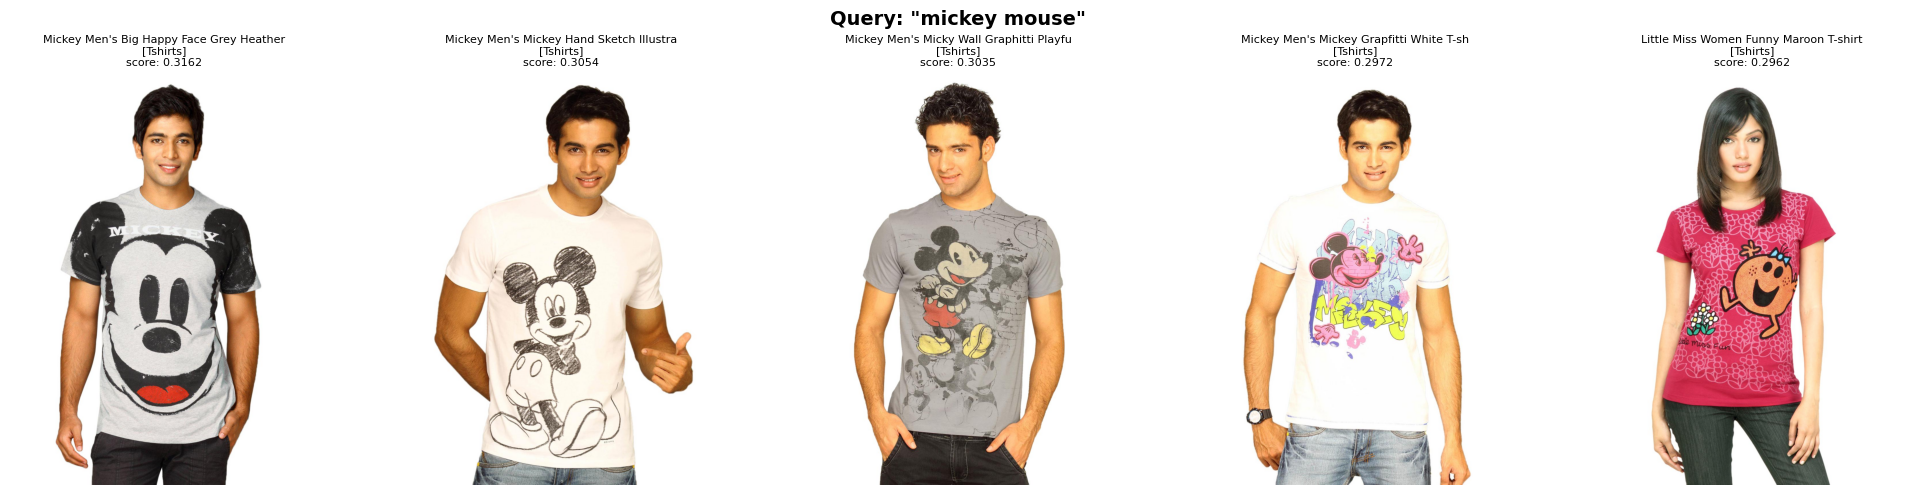

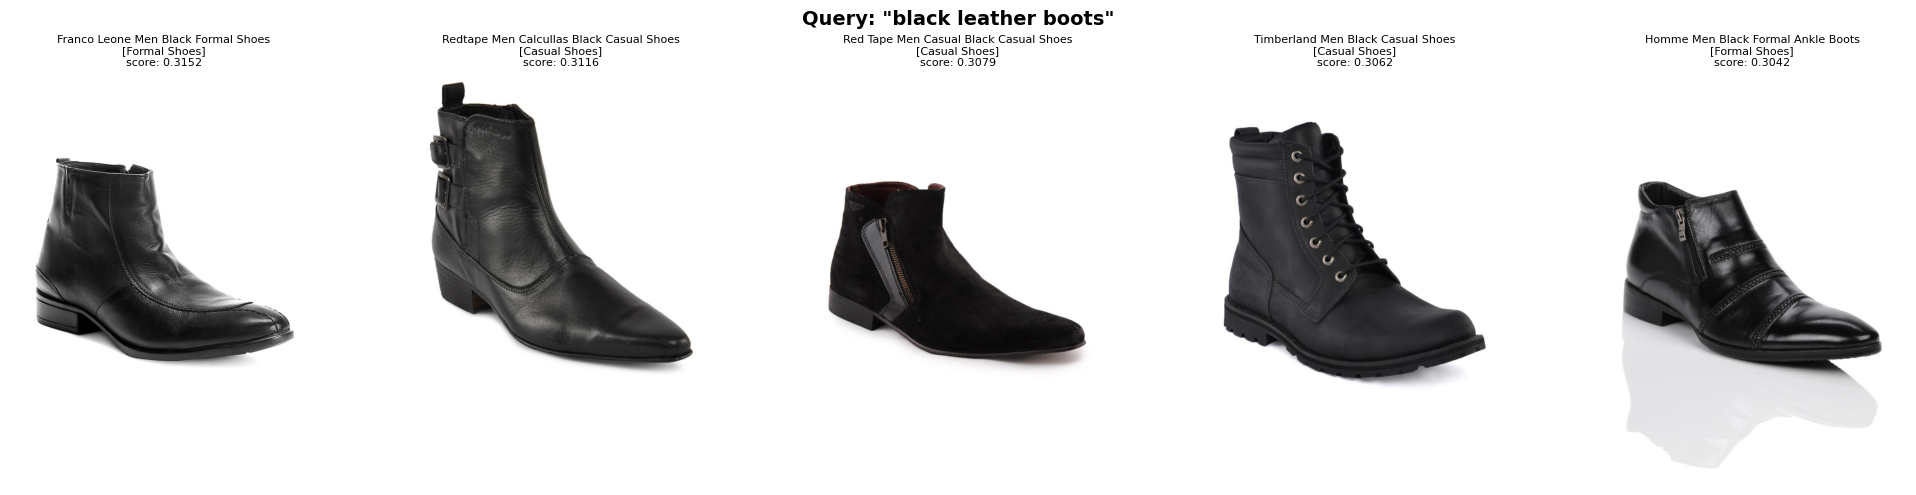

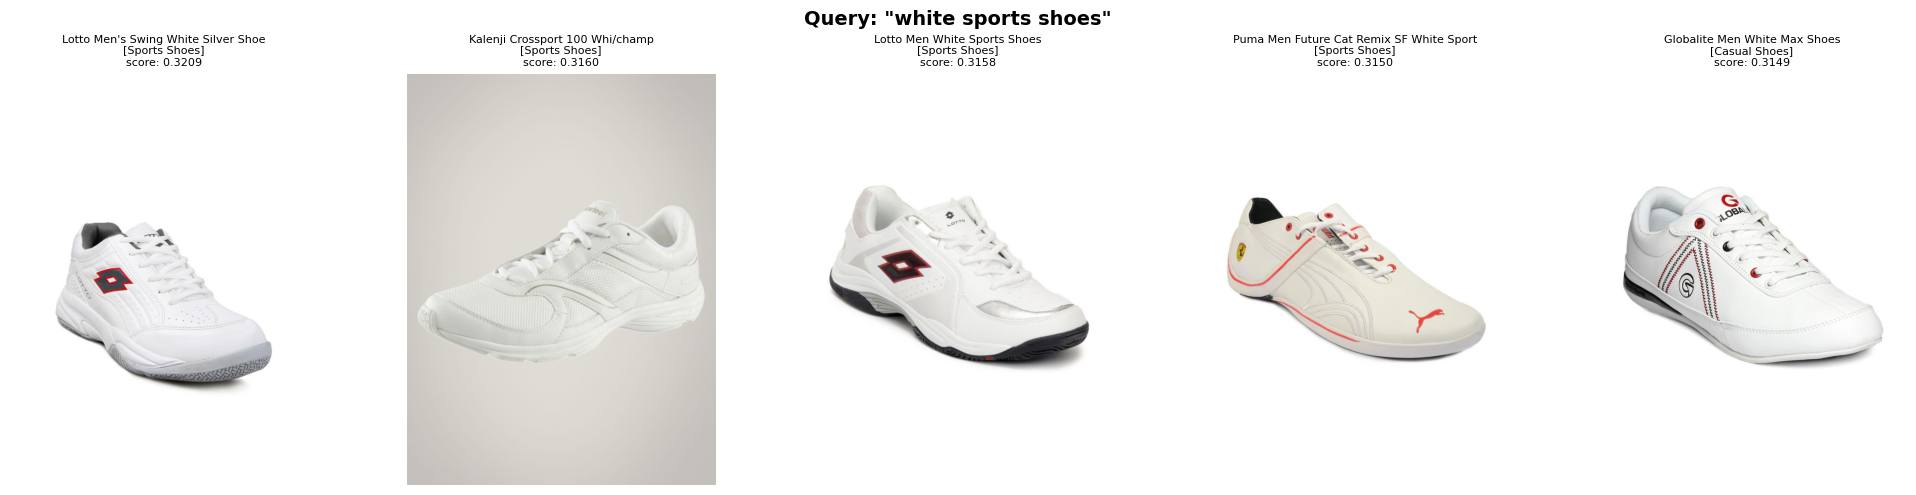

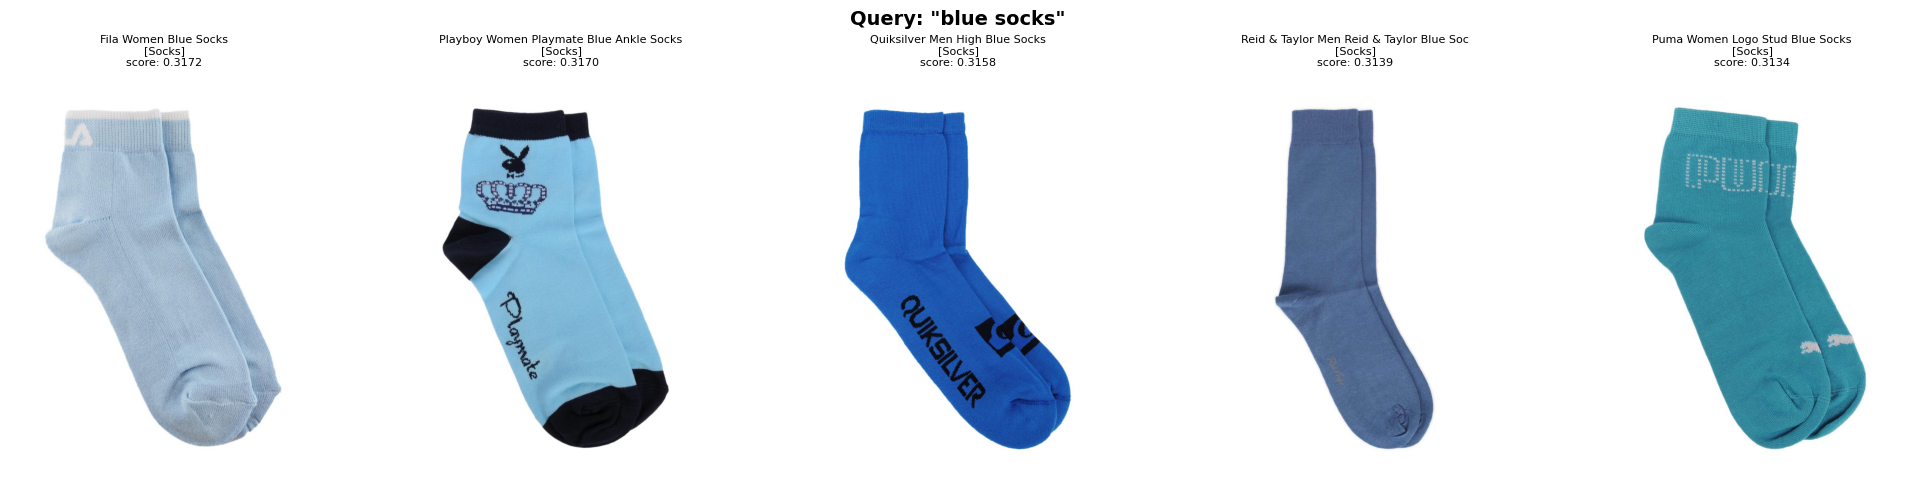

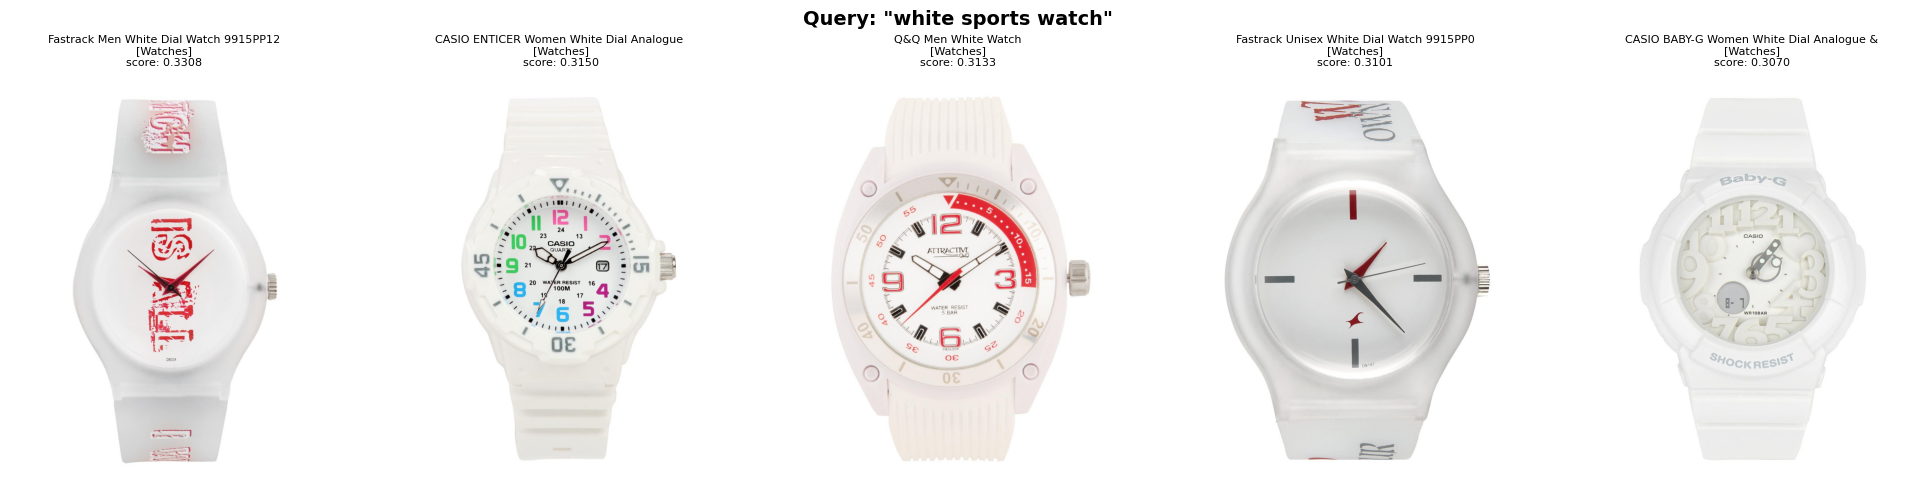

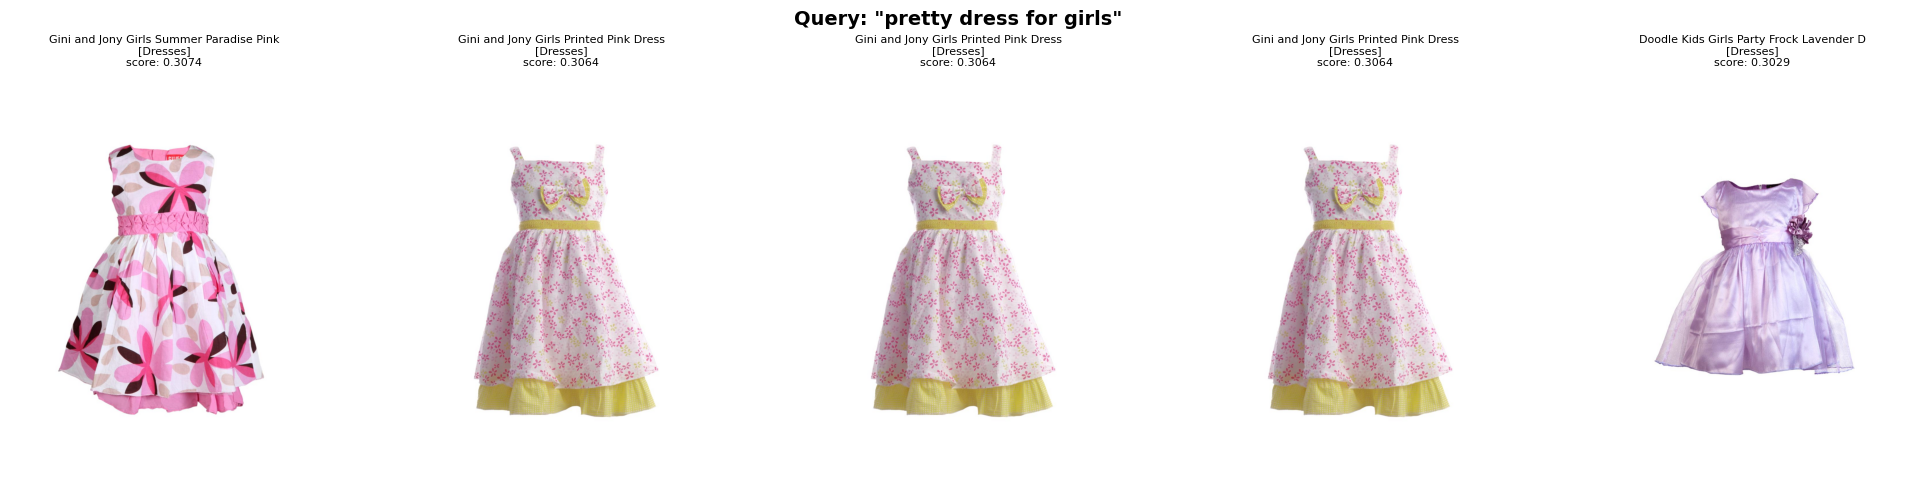

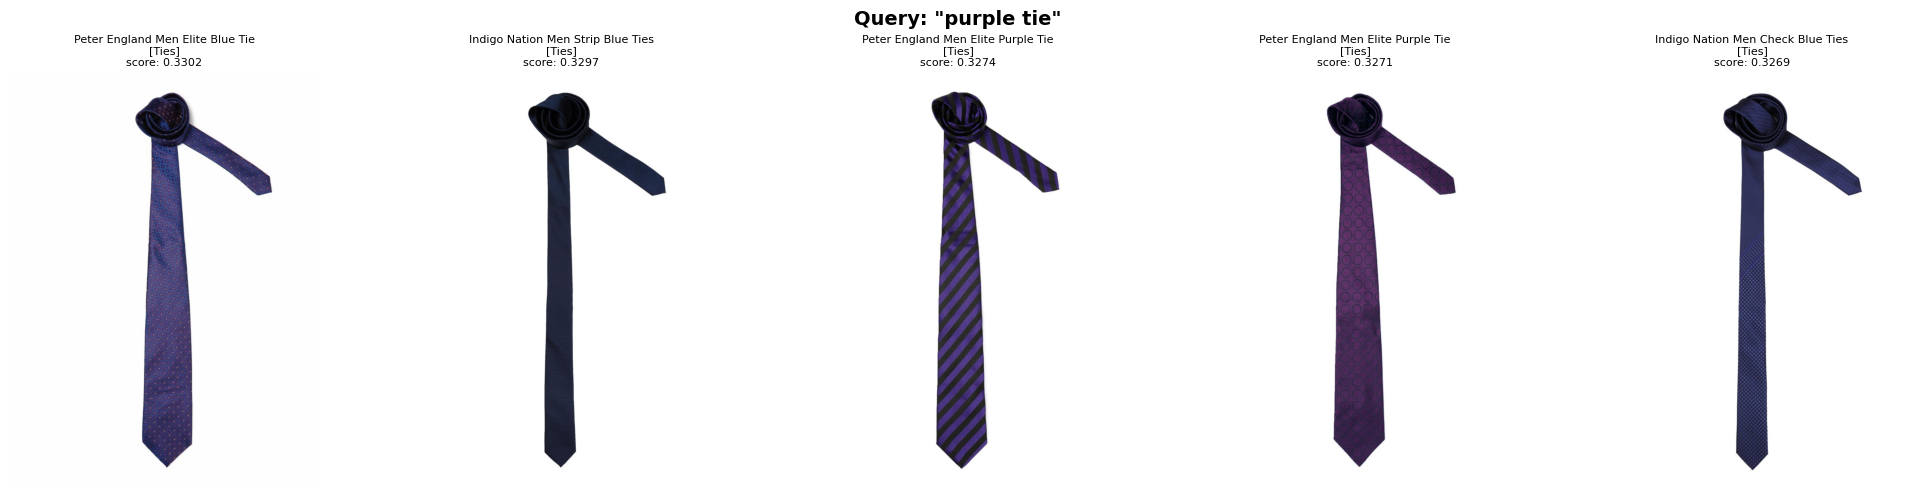

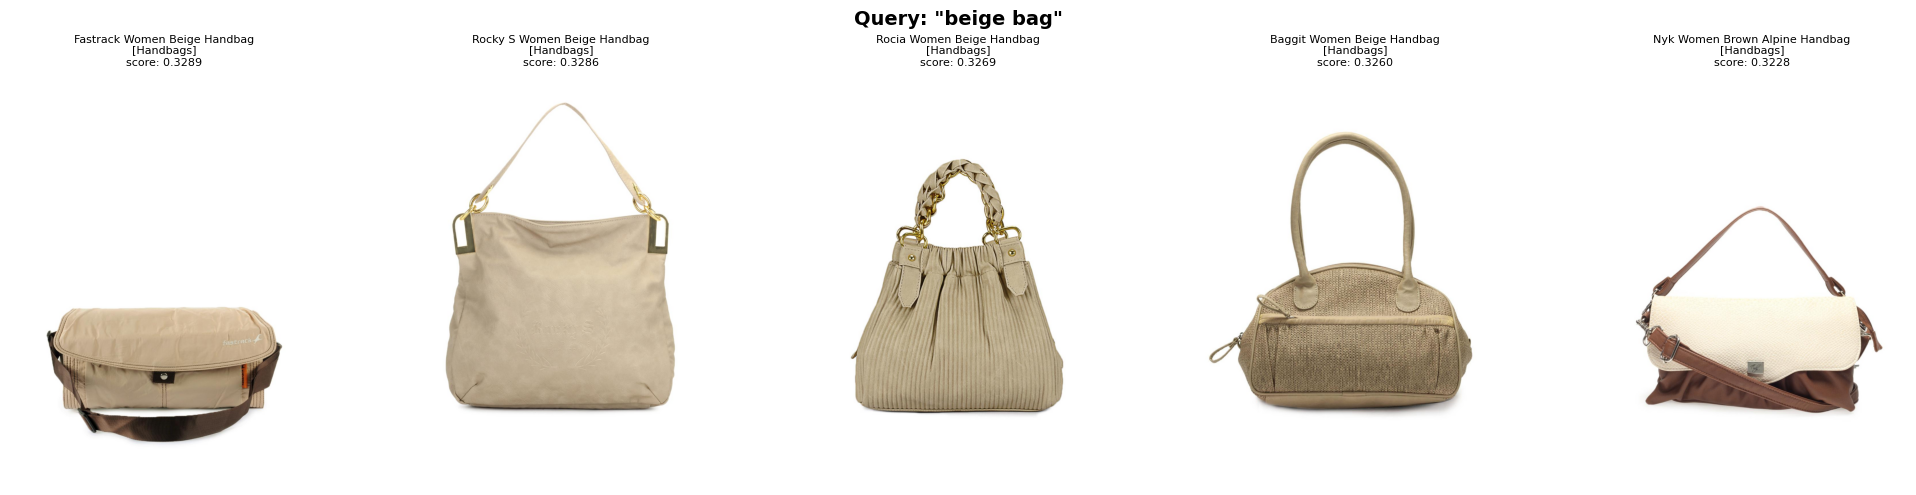

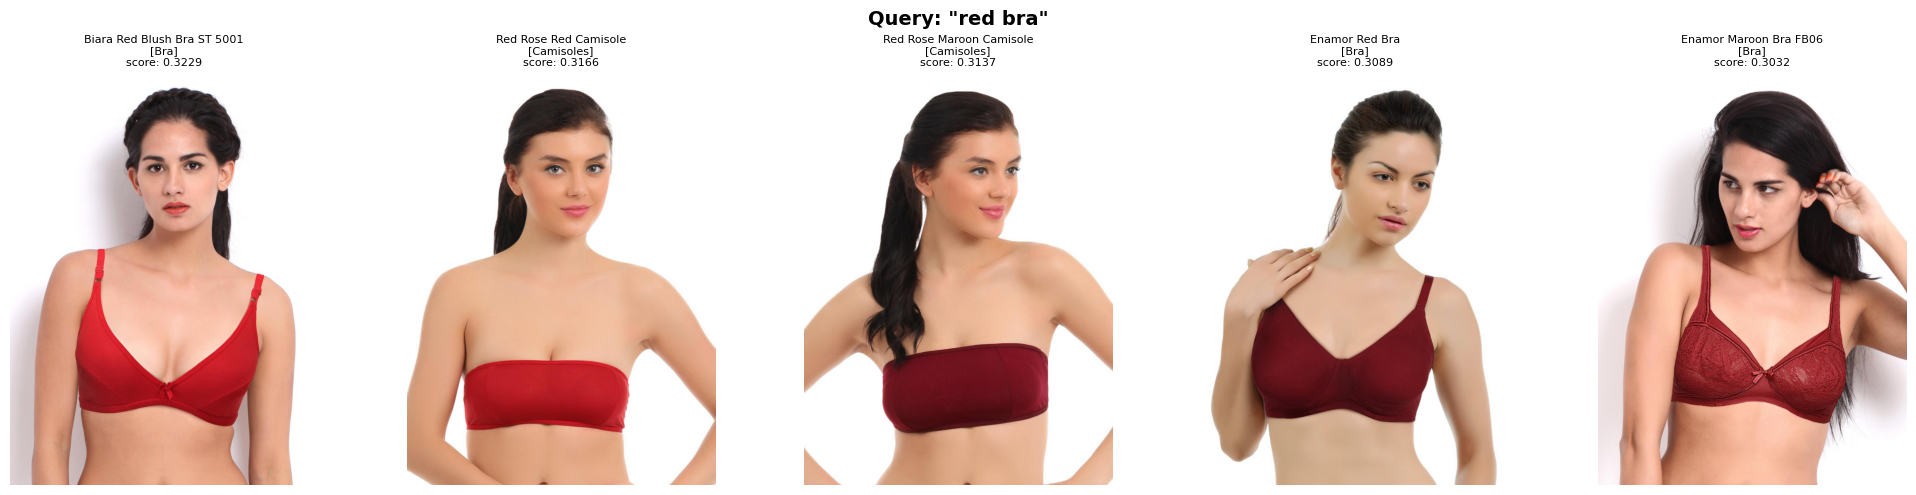

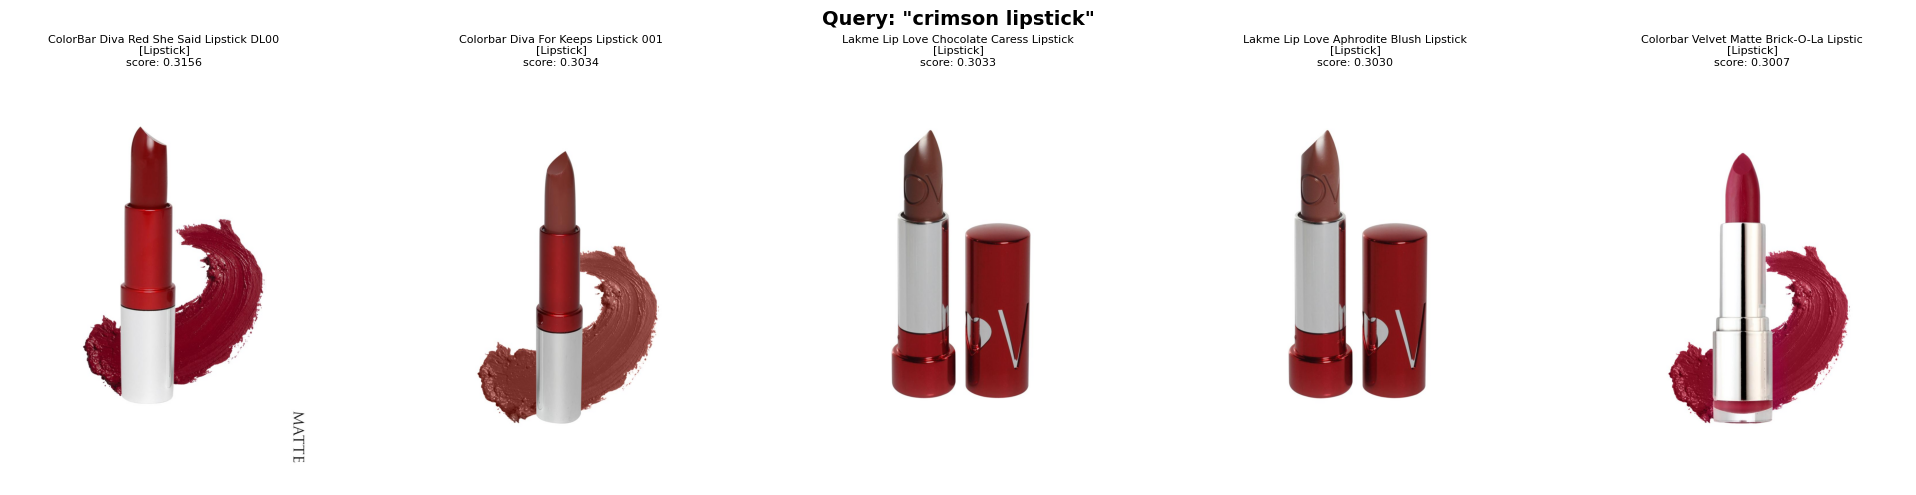

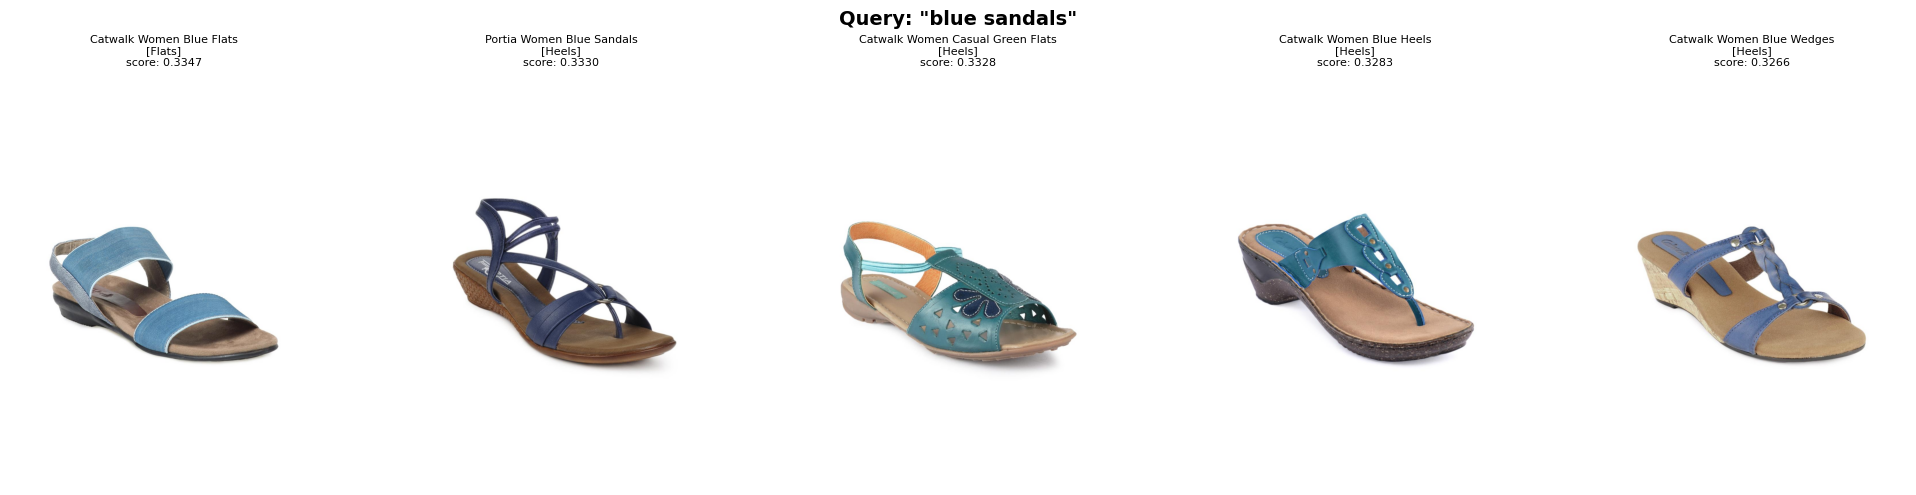

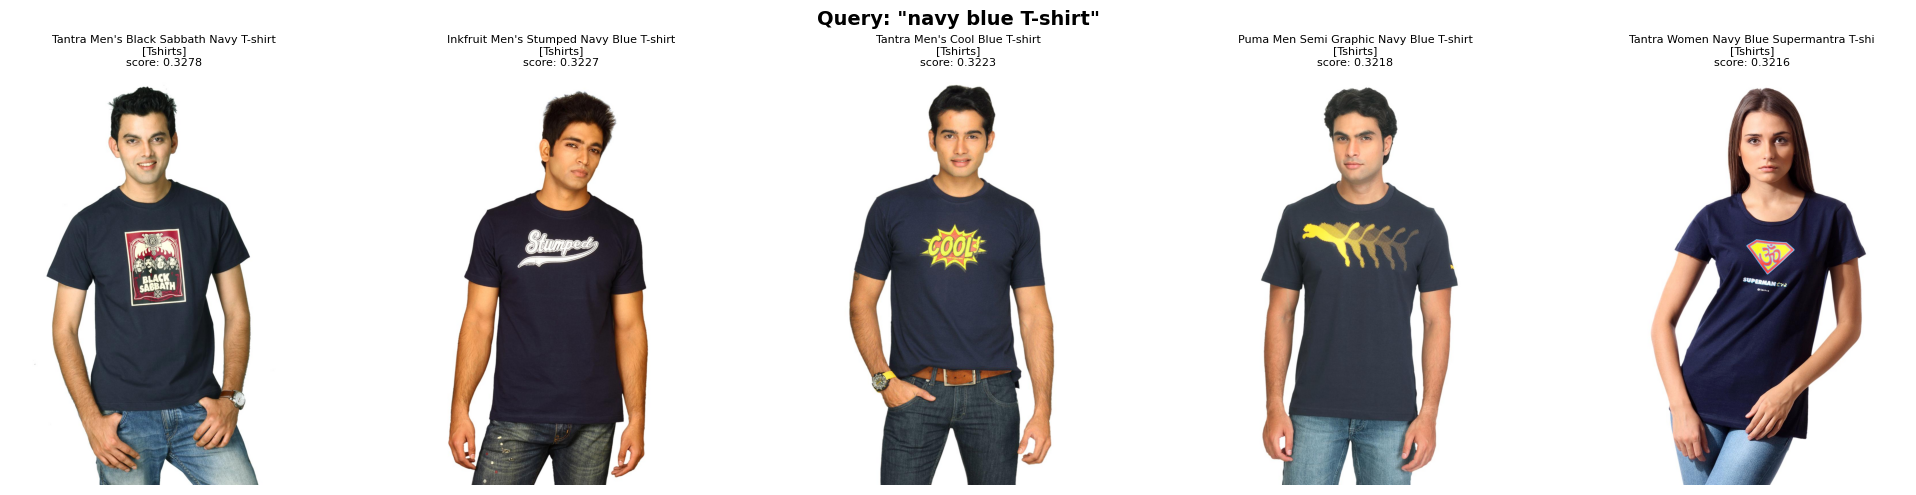

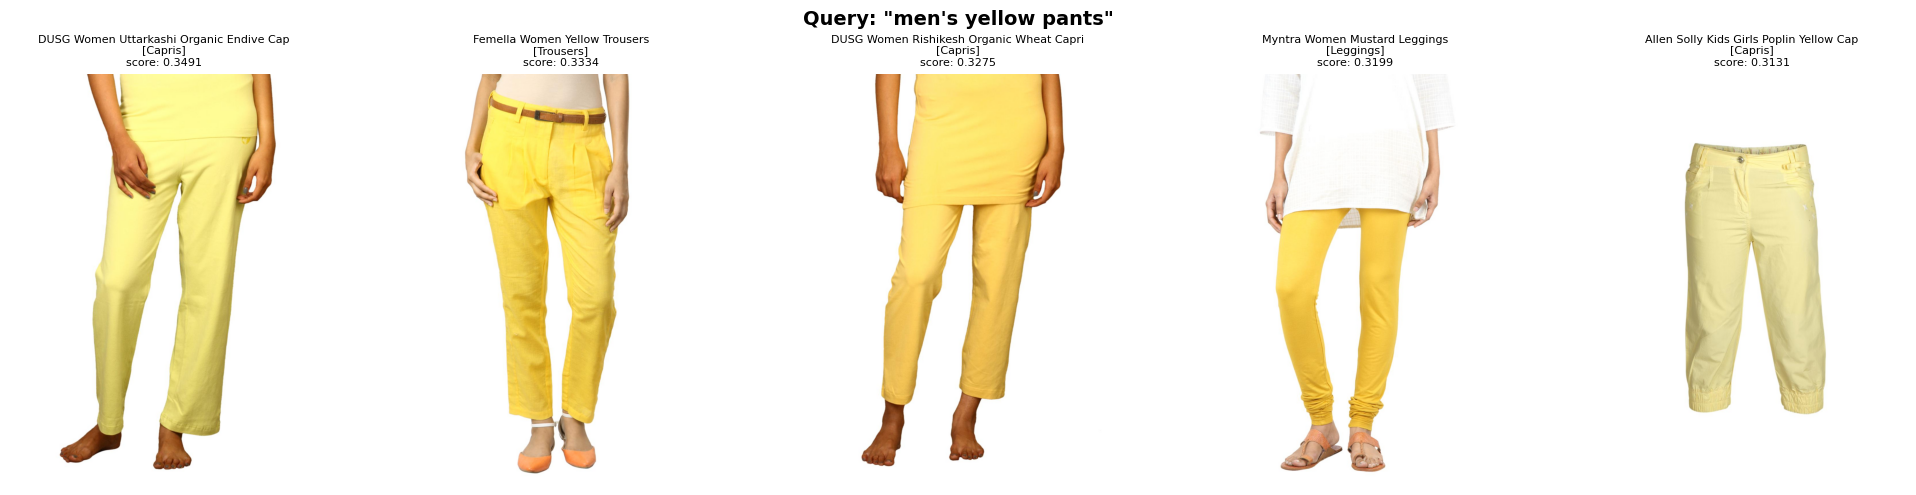

In [27]:
queries = ['red skirt', 'blue sunglasses', 'mickey mouse', 'black leather boots', 'white sports shoes', "blue socks", "white sports watch",
           'pretty dress for girls', 'purple tie', 'beige bag', 'red bra', 'crimson lipstick', 'blue sandals', 'navy blue T-shirt', "men's yellow pants"]

for query in queries:
    results = search_products(
        model=model,
        processor=processor,
        image_embeddings=image_embeddings,
        valid_indices=valid_indices,
        full_df=full_df,
        text_query=query,
        images_dir=IMAGES_DIR,
        top_k=5,
        device=device
    )
    show_search_results(results, query)

### Выводы

**Этап 1. Fine-tuning CLIP:**
- Модель `openai/clip-vit-base-patch32` дообучена на 34968 парах (image, text) за 5 эпох.
- Loss уверенно снижается, CLIP score растёт. Лучший val CLIP score = 30.57 (эпоха 3), целевое значение > 30 достигнуто.
- После эпохи 3 наблюдается лёгкое переобучение — *train score* растёт, *val* стагнирует. Для этапа 2 взят чекпоинт эпохи 3.

**Этап 2. Система поиска товаров:**
- Предвычислены эмбеддинги всех 38854 изображений. Поиск по запросу работает за доли секунды (одно матричное умножение).
- Система корректно находит товары по цвету, типу, материалу и даже абстрактным запросам ("mickey mouse" → футболки с принтами, "pretty dress for girls" → детские платья).
- Тестирование на 15 запросах показало высокую релевантность результатов по всем категориям: одежда, обувь, аксессуары, косметика.

Проект также загружен на <a href="https://disk.yandex.ru/d/9kIW5eZ99ilmtw">Яндекс Диск</a>